<a href="https://colab.research.google.com/github/Bryan-Kweku-Wilson/Data-Science/blob/main/Spotify2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — install and imports
# Install kaggle only if you plan to use Kaggle API (optional)
!pip install -q kaggle

import os, glob, zipfile, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# CELL 2 — Manual upload (best for quick use)
from google.colab import files

print("Upload your spotify CSV (e.g., spotify.csv). Use the dialog to select file(s).")
uploaded = files.upload()  # browser file-picker

# pick a csv file from uploaded
csv_files = [f for f in uploaded.keys() if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV uploaded. Re-run this cell and upload a .csv file.")
chosen_csv = csv_files[0]
print("Selected uploaded file:", chosen_csv)


Upload your spotify CSV (e.g., spotify.csv). Use the dialog to select file(s).


Saving spotify.csv to spotify.csv
Selected uploaded file: spotify.csv


In [3]:
# CELL 3 — Kaggle fallback (run only if you want to auto-download)
# Make sure you have uploaded kaggle.json previously if you run this cell.
USE_KAGGLE = False  # change to True if you want this path instead of manual upload

if USE_KAGGLE:
    DATASET_ID = "zaheenhamidani/ultimate-spotify-tracks-db"
    !mkdir -p /root/.kaggle
    # Ensure your kaggle.json was uploaded to the VM before (use files.upload in a previous cell)
    if os.path.exists('kaggle.json'):
        shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
    res = os.system(f"kaggle datasets download -d {DATASET_ID} -p /content")
    if res != 0:
        raise RuntimeError("Kaggle download failed. Check dataset id or kaggle.json.")
    # unzip first zip found
    zips = glob.glob('/content/*.zip')
    if zips:
        with zipfile.ZipFile(zips[0], 'r') as z:
            z.extractall('/content/spotify_dataset')
        # find csv
        candidates = glob.glob('/content/spotify_dataset/**/*.csv', recursive=True) + glob.glob('/content/*.csv')
        if candidates:
            chosen_csv = candidates[0]
            print("Auto-downloaded and selected:", chosen_csv)
        else:
            raise FileNotFoundError("No CSV found in downloaded zip.")
    else:
        raise FileNotFoundError("No zip downloaded by Kaggle CLI.")
else:
    print("Skipping Kaggle fallback. Using manually uploaded file.")

Skipping Kaggle fallback. Using manually uploaded file.


In [4]:
# CELL 4 — load CSV into pandas with safe options
print("Loading:", chosen_csv)
df = pd.read_csv(chosen_csv, low_memory=False, encoding='utf-8', on_bad_lines='skip')
print("Loaded DataFrame shape:", df.shape)
display(df.head())

Loading: spotify.csv
Loaded DataFrame shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# CELL 5 — normalize column names and trim whitespace
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()
print("Columns:", df.columns.tolist()[:40])

Columns: ['unnamed:_0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [6]:
# CELL 6 — missing counts, dtypes, sample stats
missing = df.isnull().sum().sort_values(ascending=False)
display(pd.concat([missing, (missing/len(df)*100).round(2)], axis=1).rename(columns={0:'missing_count',1:'missing_pct'}).head(30))
print("\nData types:")
display(df.dtypes)

,missing_count,missing_pct
unnamed:_0,0,0.0
track_id,0,0.0
artists,0,0.0
album_name,0,0.0
track_name,0,0.0
popularity,0,0.0
duration_ms,0,0.0
explicit,0,0.0
danceability,0,0.0
energy,0,0.0



Data types:


,0
unnamed:_0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [8]:
# CELL 7 — core cleaning (safe defaults, explainable)
# 1) artists
if 'artists' in df.columns:
    df['artists'] = df['artists'].replace({'nan': pd.NA, 'None': pd.NA}).fillna('Unknown Artist')

# 2) popularity -> numeric, fill median
if 'popularity' in df.columns:
    df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
    df['popularity'] = df['popularity'].fillna(int(df['popularity'].median(skipna=True)))

# 3) release_date -> parse year
if 'release_date' in df.columns:
    df['release_date_parsed'] = pd.to_datetime(df['release_date'], errors='coerce', infer_datetime_format=True)
    df['release_year'] = df['release_date_parsed'].dt.year

# 4) duration_ms or duration -> prefer duration_ms if present
if 'duration_ms' in df.columns:
    df['duration_seconds'] = pd.to_numeric(df['duration_ms'], errors='coerce')/1000
elif 'duration' in df.columns:
    # try to extract numeric part
    df['duration_seconds'] = pd.to_numeric(df['duration'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
else:
    df['duration_seconds'] = np.nan

# 5) drop exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows.")

# show results
display(df[['artists','popularity','duration_seconds']].head())

Dropped 0 duplicate rows.


,artists,popularity,duration_seconds
0,Gen Hoshino,73,230.666
1,Ben Woodward,55,149.610
2,Ingrid Michaelson;ZAYN,57,210.826
3,Kina Grannis,71,201.933
4,Chord Overstreet,82,198.853


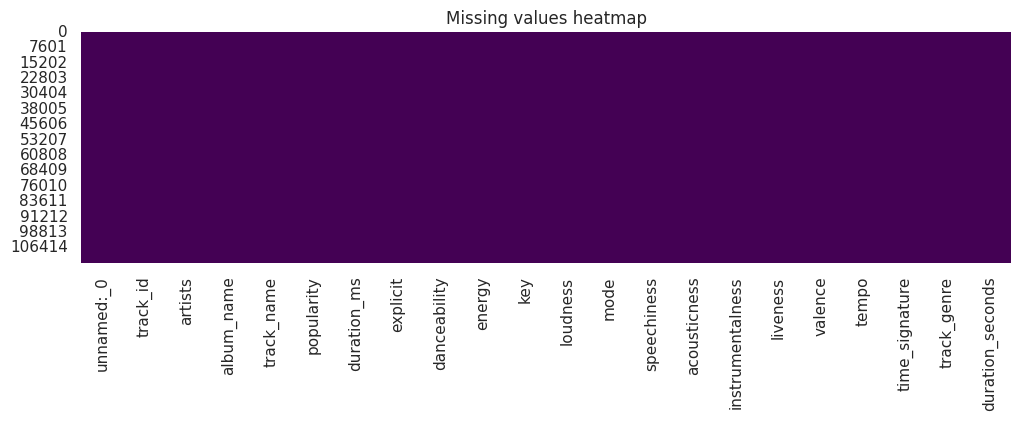

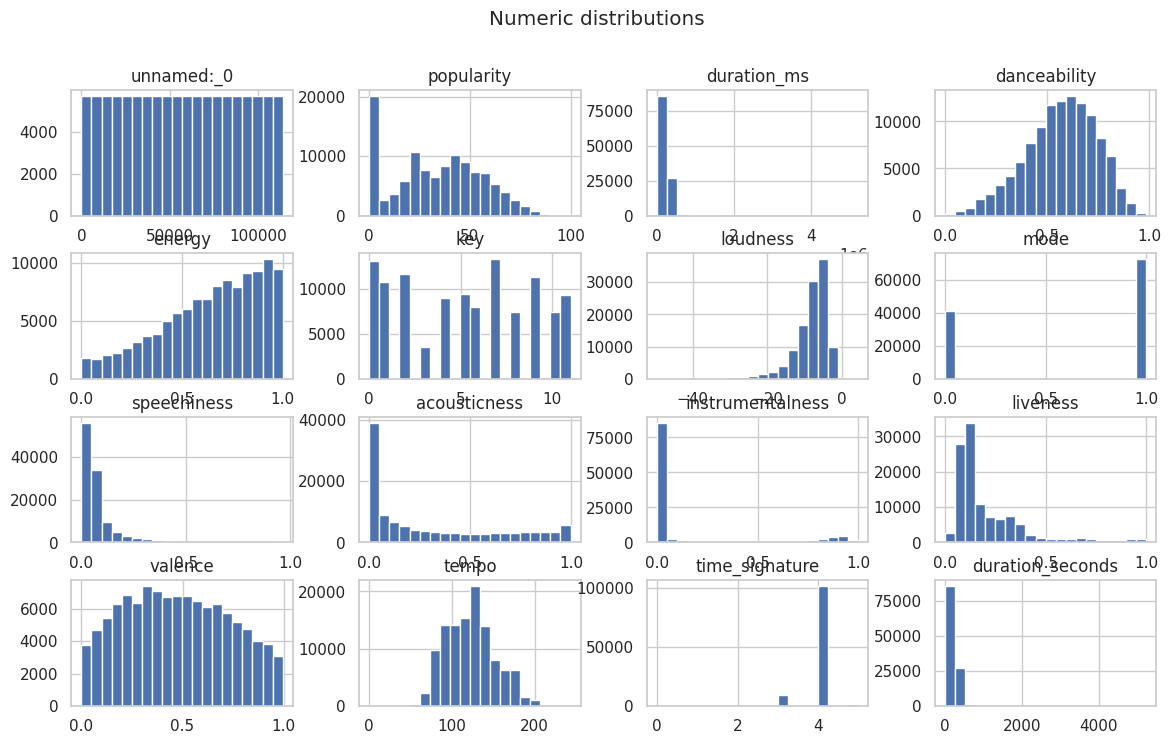

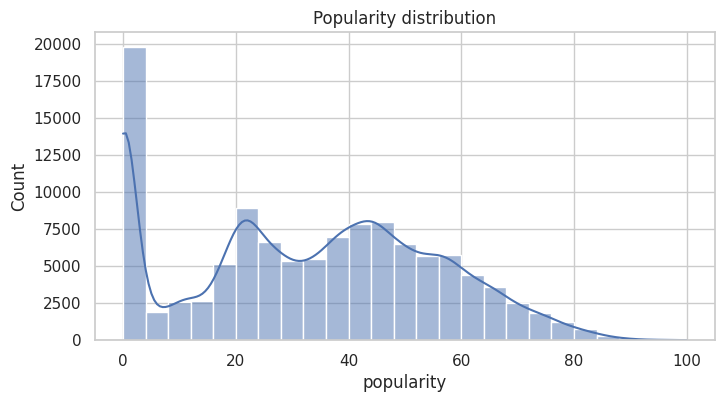

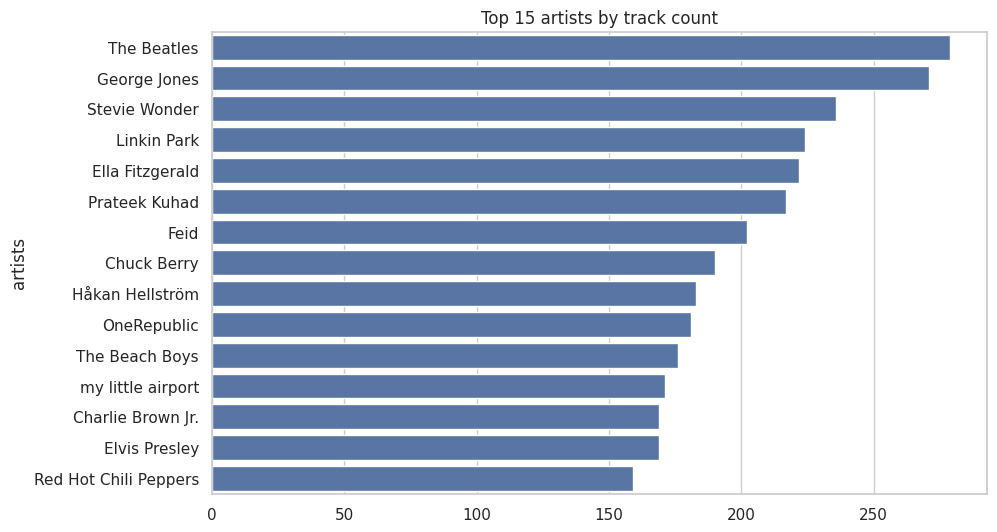

In [9]:
# CELL 8 — visuals
plt.figure(figsize=(12,3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing values heatmap'); plt.show()

num_cols = [c for c in df.select_dtypes(include=['number']).columns if c not in ('index',)]
if num_cols:
    df[num_cols].hist(figsize=(14,8), bins=20)
    plt.suptitle('Numeric distributions'); plt.show()

if 'popularity' in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['popularity'].dropna(), bins=25, kde=True)
    plt.title('Popularity distribution'); plt.show()

if 'artists' in df.columns:
    top = df['artists'].value_counts().head(15)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top.values, y=top.index)
    plt.title('Top 15 artists by track count'); plt.show()

In [10]:
# CELL 9 — save cleaned file locally and optionally to Drive
clean_name = 'cleaned_' + os.path.basename(chosen_csv)
df.to_csv(clean_name, index=False)
print("Saved cleaned CSV to", clean_name)

# Optionally copy to Drive
SAVE_TO_DRIVE = False  # set True to mount and copy
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    dst = f"/content/drive/MyDrive/{clean_name}"
    shutil.copy(clean_name, dst)
    print("Copied to Drive:", dst)

Saved cleaned CSV to cleaned_spotify.csv
